# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding,SimpleRNN


# Data Loading

In [ ]:
from google.colab import files
files.upload()
data = pd.read_csv("emoji_data.csv",header=None)

Saving emoji_data.csv to emoji_data.csv


In [ ]:
data.head()

,0,1
0,French macaroon is so tasty,4
1,work is horrible,3
2,I am upset,3
3,throw the ball,1
4,Good joke,2



# Downloading Emoji Library

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.6 MB/s eta 0:00:00


In [ ]:
import emoji

In [ ]:
emoji.emojize(":red_heart:")
#emoji.emojize(":tada")

'❤️'

# Mpapping emojis to labels

In [ ]:
emoji_dic = {
    0: ":red_heart:",
    1: ":baseball:",
    2: ":grinning_face_with_big_eyes:",
    3: ":disappointed_face:",
    4: ":fork_and_knife_with_plate:"}

def label_emoji(label):
  return emoji.emojize(emoji_dic[label])

In [ ]:
X = data[0].values
Y = data[1].values
print(Y[:5])

['4' '3' '3 ' '1 ' '2']


data[int] selects the column with that label and .values extracts underlying values and returns them as numpy arrays

# Loading Embeddings
Glove contains dense vector representation of words
utf8 is the universal text for internet encoder
ensures that while the data set is loaded byte representation of words are encoded in the correct form

In [ ]:
files.upload()
with open('glove.6B.100d.txt', 'r', encoding = 'utf8') as f:
  content = f.readlines()


Saving glove.6B.100d.txt to glove.6B.100d.txt


In [ ]:
embeddings = {}#creating a dictionary of specific words with their embeddings

for line in content:
  line = line.split() #split individual words from their global vectors representation
  embeddings[line[0]] = np.array(line[1:],dtype ='float')




In [ ]:
print(list(embeddings.items())[98])

('against', array([-0.0092921,  0.18686  ,  0.084314 , -0.26811  , -0.21608  ,
        0.84506  , -0.73735  , -0.73384  , -1.0819   ,  0.39841  ,
        0.13304  , -0.58118  , -0.53203  , -0.15233  ,  0.46465  ,
        0.2805   ,  0.020769 , -0.2033   , -0.989    ,  0.38855  ,
        0.99298  , -0.47496  ,  0.5176   ,  0.85468  ,  0.70004  ,
        0.094016 ,  0.13977  , -0.67541  , -0.23665  ,  0.22737  ,
        0.16264  ,  0.3318   ,  0.33722  , -0.21665  ,  0.0076034,
       -0.39518  , -0.087066 ,  0.0050744, -0.54576  ,  0.059273 ,
       -0.8163   , -0.49495  ,  0.29306  , -0.64932  ,  0.39675  ,
       -0.67127  ,  0.79005  , -0.52142  , -0.43738  , -1.0235   ,
       -0.07925  ,  0.85788  ,  0.1008   ,  1.6252   , -0.0061692,
       -2.253    ,  0.090421 , -0.72234  ,  1.4996   ,  0.51537  ,
       -0.79267  , -0.26272  , -0.27267  ,  0.32687  ,  0.21483  ,
        0.28405  ,  0.22274  ,  0.77563  , -0.39605  ,  0.18825  ,
        0.077636 , -0.79385  , -0.78221  , -0.5283

# Tokenizing Inputs

In [ ]:
'''
tokenizer breaks down sentences into individual words
maps  unique words to interger ID'S
'''
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer  = Tokenizer()
tokenizer.fit_on_texts(X)#perefoms tokenization
word2index=tokenizer.word_index#returns list of word to index

In [ ]:
print("Word Counts (ordered by frequency):")
print(tokenizer.word_counts)#identifies unique words with their frequencies
print("\nWord Index (word to integer mapping):")#assigns higher frequency words to lower indexes
print(tokenizer.word_index)

Word Counts (ordered by frequency):
OrderedDict({'french': 1, 'macaroon': 1, 'is': 36, 'so': 17, 'tasty': 1, 'work': 1, 'horrible': 1, 'i': 58, 'am': 17, 'upset': 1, 'throw': 1, 'the': 23, 'ball': 4, 'good': 4, 'joke': 5, 'what': 4, 'your': 8, 'favorite': 1, 'baseball': 6, 'game': 3, 'cooked': 1, 'meat': 1, 'stop': 5, 'messing': 2, 'around': 1, 'want': 8, 'chinese': 1, 'food': 6, 'let': 1, 'us': 2, 'go': 4, 'play': 2, 'you': 40, 'are': 14, 'failing': 1, 'this': 15, 'exercise': 2, 'yesterday': 1, 'we': 3, 'lost': 2, 'again': 3, 'job': 4, 'ha': 13, 'it': 7, 'was': 6, 'funny': 4, 'will': 5, 'have': 8, 'a': 21, 'cheese': 1, 'cake': 1, 'why': 1, 'feeling': 1, 'bad': 4, 'to': 16, 'never': 2, 'said': 3, 'yes': 3, 'for': 12, 'party': 1, 'cancelled': 1, 'where': 2, 'frustrated': 1, 'lol': 3, 'she': 12, 'he': 12, 'got': 7, 'raise': 1, 'family': 1, 'all': 1, 'can': 2, 'pitch': 1, 'really': 1, 'well': 2, 'love': 9, 'stars': 1, 'and': 3, 'back': 1, 'do': 6, 'like': 7, 'pizza': 1, 'totally': 1, 'des

In [ ]:
sent2int= tokenizer.texts_to_sequences(X)#converts mapped integers to the sentences in which they appeared

In [ ]:
#getting the longest tokenized sentence

maxlen = max(len(sent) for sent in sent2int)
print(maxlen)


10


#Padding by longest list

In [ ]:
'''
pad sequences standardizes inputs to be of the same length
maxlen is the maximum length each sequence should be
padding  = 'post' indicates that padding should be towards the end
truncating = ensures that sentences longer than the max length to be truncated from the end(post)
'''
from keras.preprocessing.sequence import pad_sequences
Xtrain = pad_sequences(sent2int,maxlen = maxlen,padding = 'post',truncating = 'post')

In [ ]:
print(Xtrain[:5])

[[103 104   3   6 105   0   0   0   0   0]
 [106   3 107   0   0   0   0   0   0   0]
 [  1   7 108   0   0   0   0   0   0   0]
 [109   4  35   0   0   0   0   0   0   0]
 [ 36  30   0   0   0   0   0   0   0   0]]


In [ ]:
import pandas as pd
from tensorflow.keras.utils import to_categorical

# Clean the Y array by stripping whitespaces
Y_series = pd.Series(Y).str.strip()

# Step 2: Convert to string labels to numeric
# replaces non integers like(0v2) to NAN values
Y_numeric = pd.to_numeric(Y_series, errors='coerce')

# removes raws with NAN values
#Extracts the indexes of the valid entries
valid_indices = Y_numeric.dropna().index

#extracts the values of valid entries
#converts them to integer
#converts them to nparrays
Y_cleaned = Y_numeric.loc[valid_indices].astype(int).values

# align with the Xvalues
# Since some rows were removed from Y
#Their corresponsing inputs in X should be to
Xtrain = Xtrain[valid_indices]

# converts why values to one hot encoding
Y_train = to_categorical(Y_cleaned)

In [ ]:
print(len(Y))
print(len(X))
print(len(Xtrain))
print(len(valid_indices))

183
183
182
182


In [ ]:
print(X[182])

I like it when people smile


In [ ]:
print(Xtrain[181])

[  1  24  22 311 312  60   0   0   0   0]


In [ ]:
print(valid_indices[:35])

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 32, 33, 34, 35],
      dtype='int64')


# Creating LSTM model

In [ ]:
# Each word in the vocabulary should be represeted with its unique dense vector representation
embed_size = 100
embedding_matrix = np.zeros((len(word2index)+1,embed_size))

#filtering vocabulary words vectors in the main global vocabulary

for word,intrep in word2index.items():
  embedding_matrix[intrep]= embeddings[word] #gets dense vectors for vocabulary words


In [ ]:
# accounts for the extra token that was added suring padding
# created by the np.zeros and by adding an extra row space
#such that all vocabulary words will be looped through
#and their respective dense vectors returned
#and then the extra space/row in np.zeros will be left with zeros
#which tells the embedding layer that 0 has no dense vector representation since its not a word
embedding_matrix[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
model = Sequential([
    Embedding(input_dim = len(word2index) + 1,#size of vocabulary
              output_dim = embed_size,
              input_length = maxlen,#size of actual inputs
              weights = [embedding_matrix],#mappings of wordint to their embeddings

              trainable = False),
    LSTM(units = 16, return_sequences= True),
    LSTM(units = 4),
    Dense(5, activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(




### What is an Embedding Layer?

In NLP, words are typically represented as integers (from your `word2index` mapping). However, simply using these integer IDs directly in a neural network is problematic:

1.  **Arbitrary Relationship:** The numerical distance between word IDs (e.g., word 1 and word 2) doesn't carry any semantic meaning. The network would falsely learn that word 2 is somehow 'closer' to word 1 than word 100.
2.  **High Dimensionality (One-Hot Encoding):** While one-hot encoding (where each word is a vector of zeros with a single '1') solves the arbitrary relationship issue, it results in extremely sparse and high-dimensional vectors (one dimension per word in your vocabulary), which is computationally inefficient and doesn't capture semantic similarity.

An **Embedding Layer** solves these issues by:

*   **Learning Dense Representations:** It maps each word ID to a dense, low-dimensional vector (an 'embedding'). These vectors are typically much smaller than one-hot vectors.
*   **Capturing Semantic Similarity:** During training, the network learns to adjust these embedding vectors such that words with similar meanings (or similar contexts) end up having similar vector representations (i.e., their vectors are close to each other in the embedding space).

Think of it as a lookup table: when you feed a word ID to the embedding layer, it looks up the corresponding dense vector in its internal table and outputs that vector.

### Explanation of Parameters:

1.  **`input_dim = len(word2index) + 1`**
    *   **Purpose:** This specifies the size of your vocabulary, i.e., the total number of unique words (or tokens) that the embedding layer will represent. Each unique word will get a unique embedding vector.
    *   **`len(word2index)`:** This gives you the number of unique words found by your `Tokenizer`. Since `word2index` typically starts indexing from 1 (or 0 for padding/unknown words), adding `+ 1` accounts for all possible indices, including the `0` that `pad_sequences` uses for padding. If your `tokenizer.word_index` maps words to indices 1 to N, then `input_dim` will be `N+1` to cover index 0 as well.

2.  **`output_dim = embed_size`**
    *   **Purpose:** This defines the dimensionality of the dense embedding vectors. Each word will be represented by a vector of this size. For example, if `embed_size` is 100, then each word will be converted into a 100-dimensional vector.
    *   **`embed_size` (in your code, `100`):** This is a hyperparameter you choose. Common values range from 50 to 300 (or more). A higher `output_dim` allows for more information to be captured per word but also increases model complexity.

3.  **`input_length = maxlen`**
    *   **Purpose:** This specifies the length of the input sequences that the Embedding layer expects. After `pad_sequences`, all your input sentences (`Xtrain`) have been standardized to this length.
    *   **`maxlen` (in your case, `10`):** This value ensures that the output of the Embedding layer has a consistent shape. For each input sequence of `maxlen` integers, the Embedding layer will output a `maxlen` x `output_dim` tensor. For example, if `maxlen=10` and `output_dim=100`, the output for one sentence will be a `(10, 100)` tensor.

### How it works with your data (`Xtrain`):

When you pass your `Xtrain` (which contains sequences of integer word IDs) to this `Embedding` layer:

1.  Each integer ID in `Xtrain` is looked up in the embedding matrix (which is initially randomly initialized or pre-trained).
2.  The corresponding dense vector (of `embed_size` dimensions) is retrieved.
3.  For each sequence of `maxlen` IDs, the layer outputs a sequence of `maxlen` embedding vectors.

This output is then fed into subsequent layers of your neural network, such as LSTM or SimpleRNN layers, which can then learn patterns from these rich, dense word representations.

# Compiling Model

In [ ]:
model.compile(optimizer = 'adam',loss = 'categorical_crossentropy',metrics = ['accuracy'])

#Training Model

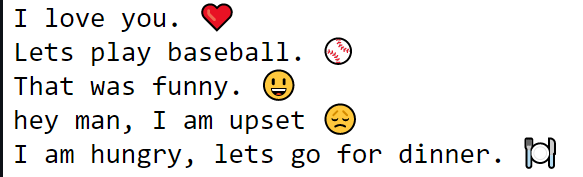

In [ ]:
model.fit(Xtrain,Y_train,epochs = 50)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1374 - loss: 1.6199
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2637 - loss: 1.5995
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3132 - loss: 1.5830
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3077 - loss: 1.5700
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3132 - loss: 1.5589
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3187 - loss: 1.5454
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3516 - loss: 1.5285
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3846 - loss: 1.5106
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4560 - loss: 1.4882
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4780 - loss: 1.4624
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4945 - loss: 1.4303
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5000 - loss: 1.3950
E

# Evaluating Models Perfomance

 Since the model was trained on a limited vocan the testing data should have its vocabulary from the vocab used currently but structured differently

In [ ]:
vocab = list(word2index.keys())
vocab.sort()
print(vocab)

'dinner' in vocab

['a', 'acceptance', 'achievements', 'adorable', 'adore', 'after', 'afternoon', 'again', 'algorithm', 'all', 'alone', 'always', 'am', 'amazing', 'an', 'and', 'announcement', 'answer', 'any', 'anything', 'approved', 'are', 'around', 'ask', 'assignment', 'at', 'attractive', 'away', 'awesome', 'awful', 'baby', 'back', 'bad', 'ball', 'base', 'baseball', 'be', 'best', 'birthday', 'boiled', 'boring', 'bravo', 'break', 'breakfast', 'breaks', 'brighten', 'brunch', 'bullshit', 'bully', 'but', 'by', 'cake', 'can', 'cancelled', 'candy', 'cannot', 'catcher', 'celebrate', 'charming', 'cheese', 'chicago', 'chinese', 'code', 'come', 'coming', 'congrats', 'congratulation', 'congratulations', 'cooked', 'cookies', 'could', 'cubs', 'cute', 'cutest', 'dad', 'dance', 'dare', 'date', 'day', 'dear', 'dearest', 'dedication', 'deserve', 'did', 'dinner', 'disappointed', 'do', 'dog', 'dogs', 'down', 'during', 'eat', 'end', 'enjoy', 'ever', 'exam', 'excited', 'exercise', 'failed', 'failing', 'family', 'favorite', 

True

In [ ]:
test_data = ["I am so happy at my achievements","Lets have dinner ","I adore you","why is he sad at me","stop him at work"]
test_seq = tokenizer.texts_to_sequences(test_data)
y_pred = pad_sequences(test_seq,maxlen = maxlen,padding = 'post',truncating='post')



# Models Perfomance on test data

In [ ]:
predictions = model.predict(y_pred)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[0.29918462 0.04308274 0.52898884 0.07452147 0.05422225]
 [0.01643511 0.08267302 0.24480821 0.29978916 0.3562945 ]
 [0.4246379  0.04221508 0.40972546 0.07485513 0.0485664 ]
 [0.04001459 0.03431683 0.02710527 0.61814106 0.2804223 ]
 [0.03707556 0.0355623  0.03018078 0.6058463  0.29133514]]


In [ ]:
for i,prediction in enumerate(predictions):
  class_id = np.argmax(prediction)
  print(f"{test_data[i]} {label_emoji(class_id)}")

I am so happy at my achievements 😃
Lets have dinner  🍽️
I adore you ❤️
why is he sad at me 😞
stop him at work 😞


In [ ]:
print(emoji_dic)

{0: ':red_heart:', 1: ':baseball:', 2: ':grinning_face_with_big_eyes:', 3: ':disappointed_face:', 4: ':fork_and_knife_with_plate:'}
